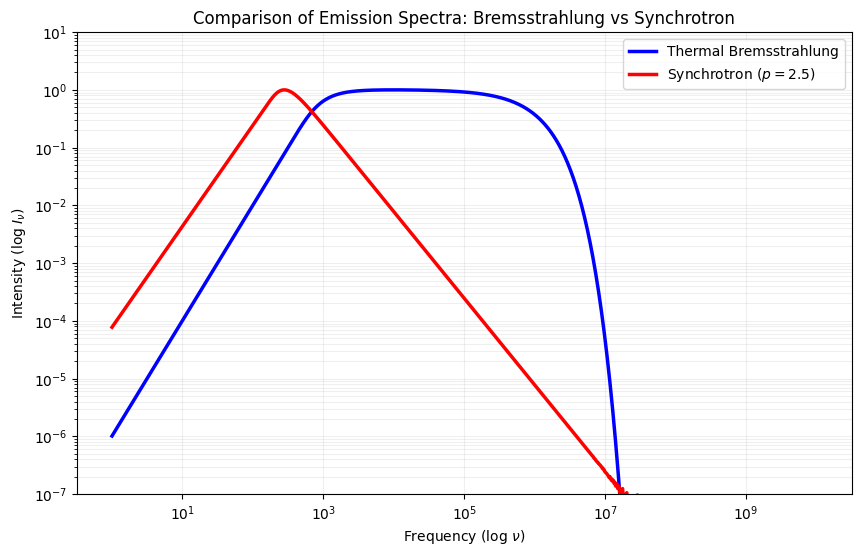

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Frequency range (log scale)
nu = np.logspace(0, 10, 1000)

# --- 1. Thermal Bremsstrahlung ---
T_brem = 100000
# Optically thick part (nu^2) and Optically thin part (nu^0 * exp(-nu))
# Combined using a smooth transition: I = B_nu * (1 - exp(-tau))
tau_brem = 1e6 * nu**-2
B_nu_brem = nu**2 # Rayleigh-Jeans
j_nu_brem = np.exp(-nu / (T_brem * 10)) # Exponential cutoff
I_brem = B_nu_brem * (1 - np.exp(-tau_brem)) * j_nu_brem

# --- 2. Synchrotron (Power-law Distribution) ---
p = 2.5 # Electron index
s = (p - 1) / 2 # Spectral index = 0.75
# Optically thick (nu^2.5) and Optically thin (nu^-s)
tau_sync = 1e8 * nu**(-(p + 4) / 2)
S_nu_sync = nu**2.5 # Source function for synchrotron
I_sync = S_nu_sync * (1 - np.exp(-tau_sync)) * (nu**-s)

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.loglog(nu, I_brem / np.max(I_brem), label='Thermal Bremsstrahlung', color='blue', lw=2.5)
plt.loglog(nu, I_sync / np.max(I_sync), label='Synchrotron ($p=2.5$)', color='red', lw=2.5)

# Adding slope markers for clarity

plt.title('Comparison of Emission Spectra: Bremsstrahlung vs Synchrotron')
plt.xlabel('Frequency (log $\\nu$)')
plt.ylabel('Intensity (log $I_\\nu$)')
plt.ylim(1e-7, 10)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()